# PRUEBAS DE CLUSTERING APLICADO AL DATASET ELECTORAL LAPOP 2023

### INICIALIZACIÓN

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np

from src.clustering.traditional import KMedoids, HierarchicalClustering, DBSCAN
from src.evaluation import calculate_metrics
from src.utils.constants import PROCESSED_DATA_PATH

print("="*70)
print("TEST SIMPLE DE ALGORITMOS DE CLUSTERING")
print("="*70)

# Cargar dataset preprocesado
dataset_path = f"{PROCESSED_DATA_PATH}"
df = pd.read_csv(dataset_path)

print(f"\n✓ Dataset cargado:")
print(f"  Dimensiones: {df.shape[0]} registros × {df.shape[1]} variables")
print(f"  Missings: {df.isnull().sum().sum()}")
print(f"\nPrimeras 3 filas:")
print(df.head(3))
print("="*70)

TEST SIMPLE DE ALGORITMOS DE CLUSTERING

✓ Dataset cargado:
  Dimensiones: 1706 registros × 28 variables
  Missings: 0

Primeras 3 filas:
       edre    q10inc  etid  boletidnew  boletidnewb  estratopri   ur  \
0  1.000000  0.000000   0.2         1.0        0.250         0.0  1.0   
1  0.166667  0.285714   0.2         0.0        0.000         0.0  1.0   
2  0.500000  0.571429   0.2         1.0        0.125         0.0  1.0   

    ocupoit        q2  q1tc_r  ...  estratosec  q12cn  q12bn  gi0n  smedia3n  \
0  0.555556  0.485714     0.5  ...         0.0  0.000    0.0   0.0      0.00   
1  0.777778  0.528571     0.0  ...         0.0  0.250    0.3   0.0      0.75   
2  1.000000  0.185714     0.0  ...         1.0  0.375    0.3   0.0      0.75   

   q10e  q11n  leng4  wealth_index  civic_index  
0   0.5   0.0   0.25           0.6     0.416667  
1   1.0   0.2   0.25           0.7     0.000000  
2   1.0   0.4   0.50           0.6     0.416667  

[3 rows x 28 columns]


### APLICACIÓN DE LOS ALGORITMOS

##### K-MEDOIDS


In [2]:
print("\n--- BÚSQUEDA DE CONFIGURACIÓN - K-MEDOIDS ---\n")

k_range = range(2, 12)  # Limitado a 12 de acuerdo a la regla de Sturges k_max = 1 + log₂(n) → con n=1706 → k ≈ 11
resultados_k = []

for k in k_range:
    km_temp = KMedoids(n_clusters=k, random_state=42)
    km_temp.fit(df)
    metrics_temp = calculate_metrics(df, km_temp.labels_)
    resultados_k.append({
        'k': k,
        'inercia': km_temp.inertia_,
        'silhouette': metrics_temp['silhouette'],
        'davies_bouldin': metrics_temp['davies_bouldin']
    })
    print(f"  k={k}: Inercia={km_temp.inertia_:.2f} | "
          f"Sil={metrics_temp['silhouette']:.4f} | "
          f"DB={metrics_temp['davies_bouldin']:.4f}")

# Criterio compuesto: normalizar ambas métricas y combinarlas
# Silhouette: mayor es mejor → normalizar y maximizar
# Davies-Bouldin: menor es mejor → invertir, normalizar y maximizar
sil_vals = np.array([r['silhouette'] for r in resultados_k])
db_vals  = np.array([r['davies_bouldin'] for r in resultados_k])

sil_norm = (sil_vals - sil_vals.min()) / (sil_vals.max() - sil_vals.min())
db_norm  = 1 - (db_vals - db_vals.min()) / (db_vals.max() - db_vals.min())

score_combinado = 0.6 * sil_norm + 0.4 * db_norm  # silhouette pesa más

mejor_idx = np.argmax(score_combinado)
k_optimo  = resultados_k[mejor_idx]['k']

print(f"\n  k óptimo por Silhouette:       k={resultados_k[np.argmax(sil_vals)]['k']}")
print(f"  k óptimo por Davies-Bouldin:   k={resultados_k[np.argmin(db_vals)]['k']}")
print(f"  k óptimo por criterio compuesto (60% Sil + 40% DB): k={k_optimo}")


--- BÚSQUEDA DE CONFIGURACIÓN - K-MEDOIDS ---

Entrenando K-Medoids con 2 clusters...
✓ K-Medoids entrenado: 2 clusters identificados
  Inercia: 8953.5881
Calculando métricas de validación...
  Muestras: 1706
  Clusters: 2
  ✓ Silhouette Score: 0.1178
  ✓ Davies-Bouldin Index: 2.6546
  ✓ Calinski-Harabasz Index: 230.8875
  k=2: Inercia=8953.59 | Sil=0.1178 | DB=2.6546
Entrenando K-Medoids con 3 clusters...
✓ K-Medoids entrenado: 3 clusters identificados
  Inercia: 8349.5889
Calculando métricas de validación...
  Muestras: 1706
  Clusters: 3
  ✓ Silhouette Score: 0.0712
  ✓ Davies-Bouldin Index: 3.1387
  ✓ Calinski-Harabasz Index: 154.1534
  k=3: Inercia=8349.59 | Sil=0.0712 | DB=3.1387
Entrenando K-Medoids con 4 clusters...
✓ K-Medoids entrenado: 4 clusters identificados
  Inercia: 7953.4579
Calculando métricas de validación...
  Muestras: 1706
  Clusters: 4
  ✓ Silhouette Score: 0.0711
  ✓ Davies-Bouldin Index: 2.9717
  ✓ Calinski-Harabasz Index: 134.9239
  k=4: Inercia=7953.46 | Sil

In [3]:
print("\n--- TEST K-MEDOIDS ---\n")

# Entrenar con k óptimo
k_final = int(k_optimo)
print(f"\nEntrenando con k={k_final}...")
kmedoids = KMedoids(n_clusters=k_final, random_state=42)
kmedoids.fit(df)

# Distribución y métricas
print("\nDistribución:")
print(kmedoids.get_cluster_distribution())
print("\nMétricas:")
metrics_km = calculate_metrics(df, kmedoids.labels_)

print("="*70)


--- TEST K-MEDOIDS ---


Entrenando con k=2...
Entrenando K-Medoids con 2 clusters...
✓ K-Medoids entrenado: 2 clusters identificados
  Inercia: 8953.5881

Distribución:
   cluster  size  percentage
0        0   984   57.678781
1        1   722   42.321219

Métricas:
Calculando métricas de validación...
  Muestras: 1706
  Clusters: 2
  ✓ Silhouette Score: 0.1178
  ✓ Davies-Bouldin Index: 2.6546
  ✓ Calinski-Harabasz Index: 230.8875


##### CLUSTERING JERARQUICO

In [4]:
print("\n--- BÚSQUEDA DE CONFIGURACIÓN - CLUSTERING JERÁRQUICO ---\n")

# Evaluar linkages con múltiples n_clusters para encontrar el menor metodo
n_clusters_eval = [2, 3, 4, 5, 6, 7, 8, 9, 10]
linkage_methods  = ['ward', 'complete', 'average', 'single']
resultados_linkage = []

print("Comparando linkages (promedio de silhouette para n=3,4,5):")
for linkage in linkage_methods:
    sils = []
    for n in n_clusters_eval:
        hc_temp = HierarchicalClustering(n_clusters=n, linkage=linkage)
        hc_temp.fit(df)
        metrics_temp = calculate_metrics(df, hc_temp.labels_)
        # Solo contar si no hay clusters degenerados (menos del 1% del total)
        sizes = pd.Series(hc_temp.labels_).value_counts()
        if sizes.min() >= len(df) * 0.01:
            sils.append(metrics_temp['silhouette'])
    sil_prom = np.mean(sils) if sils else -1
    resultados_linkage.append({'linkage': linkage, 'silhouette_promedio': sil_prom})
    print(f"  {linkage:10s}: Sil promedio={sil_prom:.4f} "
          f"({'descartado por desbalance' if sil_prom == -1 else ''})")

mejor_linkage = max(resultados_linkage, key=lambda x: x['silhouette_promedio'])['linkage']
print(f"\n  Mejor linkage: '{mejor_linkage}'")

# Buscar n_clusters óptimo con el mejor linkage
print(f"\nBuscando n_clusters óptimo con linkage='{mejor_linkage}'...")
resultados_n = []
for n in range(2, 12):
    hc_temp = HierarchicalClustering(n_clusters=n, linkage=mejor_linkage)
    hc_temp.fit(df)
    sizes   = pd.Series(hc_temp.labels_).value_counts()
    # Descartar si hay cluster con menos del 1% de los datos
    if sizes.min() < len(df) * 0.01:
        print(f"  n={n}: descartado (cluster degenerado: {sizes.min()} puntos)")
        continue
    metrics_temp = calculate_metrics(df, hc_temp.labels_)
    resultados_n.append({'n': n, 'silhouette': metrics_temp['silhouette'],
                         'davies_bouldin': metrics_temp['davies_bouldin']})
    print(f"  n={n}: Sil={metrics_temp['silhouette']:.4f} | "
          f"DB={metrics_temp['davies_bouldin']:.4f}")

n_optimo = max(resultados_n, key=lambda x: x['silhouette'])['n'] if resultados_n else 3
print(f"\n  n_clusters óptimo: {n_optimo}")

print(f"\n === CONFIGURACION OPTIMA === ")
print(f" Mejor linkage: '{mejor_linkage}'")
print(f" n_clusters óptimo: {n_optimo}")


--- BÚSQUEDA DE CONFIGURACIÓN - CLUSTERING JERÁRQUICO ---

Comparando linkages (promedio de silhouette para n=3,4,5):
Entrenando Clustering Jerárquico (ward)...
✓ Clustering Jerárquico entrenado: 2 clusters
Calculando métricas de validación...
  Muestras: 1706
  Clusters: 2
  ✓ Silhouette Score: 0.1329
  ✓ Davies-Bouldin Index: 2.5382
  ✓ Calinski-Harabasz Index: 244.3418
Entrenando Clustering Jerárquico (ward)...
✓ Clustering Jerárquico entrenado: 3 clusters
Calculando métricas de validación...
  Muestras: 1706
  Clusters: 3
  ✓ Silhouette Score: 0.0906
  ✓ Davies-Bouldin Index: 2.7370
  ✓ Calinski-Harabasz Index: 182.0592
Entrenando Clustering Jerárquico (ward)...
✓ Clustering Jerárquico entrenado: 4 clusters
Calculando métricas de validación...
  Muestras: 1706
  Clusters: 4
  ✓ Silhouette Score: 0.0954
  ✓ Davies-Bouldin Index: 2.7723
  ✓ Calinski-Harabasz Index: 151.0559
Entrenando Clustering Jerárquico (ward)...
✓ Clustering Jerárquico entrenado: 5 clusters
Calculando métricas d

In [7]:
print("\n--- TEST CLUSTERING JERÁRQUICO ---\n")

# Entrenar con los parámetros encontrados
print(f"\nPaso 3: Entrenando con n_clusters={n_optimo}, linkage='{mejor_linkage}'...")
hierarchical = HierarchicalClustering(n_clusters=n_optimo, linkage=mejor_linkage)
hierarchical.fit(df)

print("\nDistribución:")
print(hierarchical.get_cluster_distribution())
print("\nMétricas finales:")
metrics_hc = calculate_metrics(df, hierarchical.labels_)

print("="*70)


--- TEST CLUSTERING JERÁRQUICO ---


Paso 3: Entrenando con n_clusters=2, linkage='complete'...
Entrenando Clustering Jerárquico (complete)...
✓ Clustering Jerárquico entrenado: 2 clusters

Distribución:
   cluster  size  percentage
0        0  1078   63.188746
1        1   628   36.811254

Métricas finales:
Calculando métricas de validación...
  Muestras: 1706
  Clusters: 2
  ✓ Silhouette Score: 0.1339
  ✓ Davies-Bouldin Index: 2.4596
  ✓ Calinski-Harabasz Index: 255.5461



--- DENDROGRAMA - CLUSTERING JERÁRQUICO ---

✓ Dendrograma guardado en: ../../figures/dendrograma_completo.png


C:\Users\pabli\AppData\Local\Temp\ipykernel_23932\1053665367.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()


✓ Dendrograma guardado en: ../../figures/dendrograma_truncado.png


AttributeError: 'Axes' object has no attribute 'show'

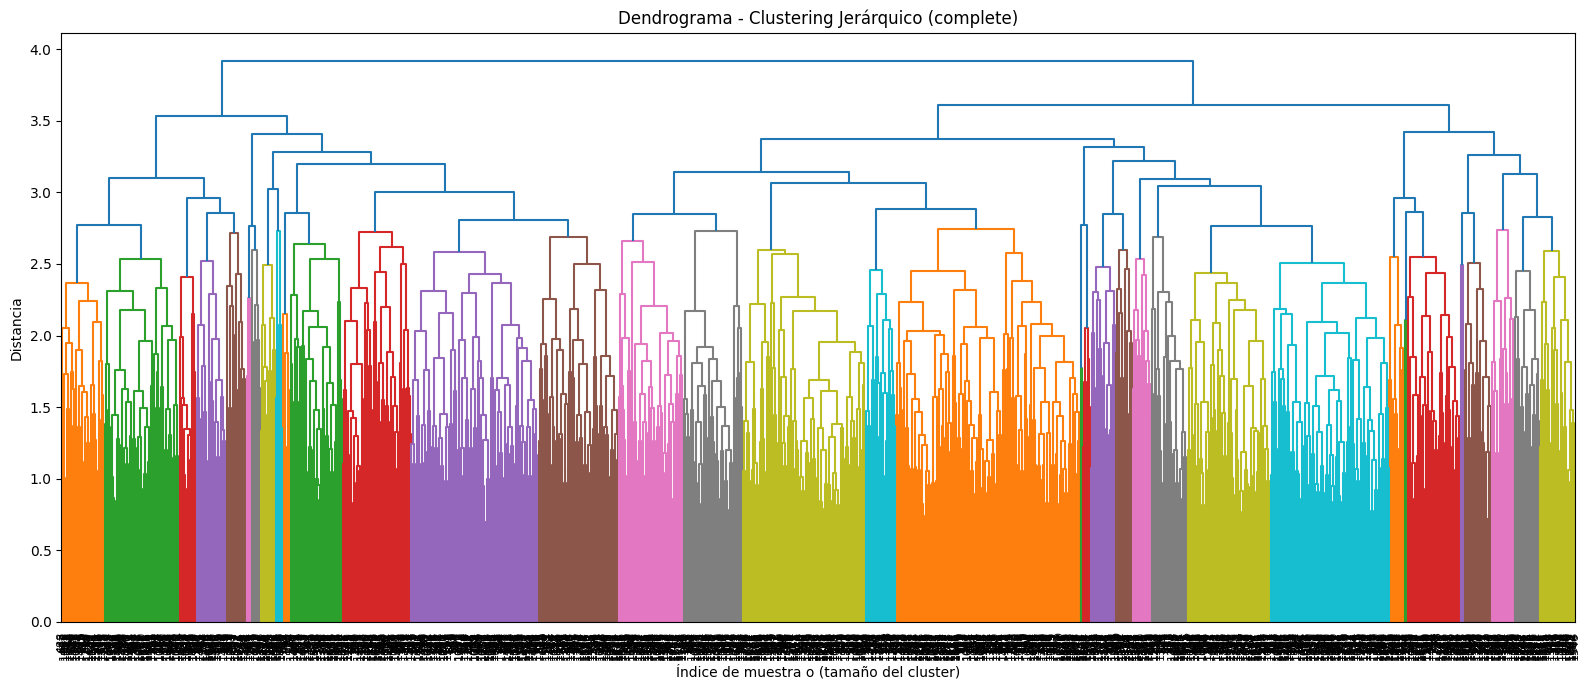

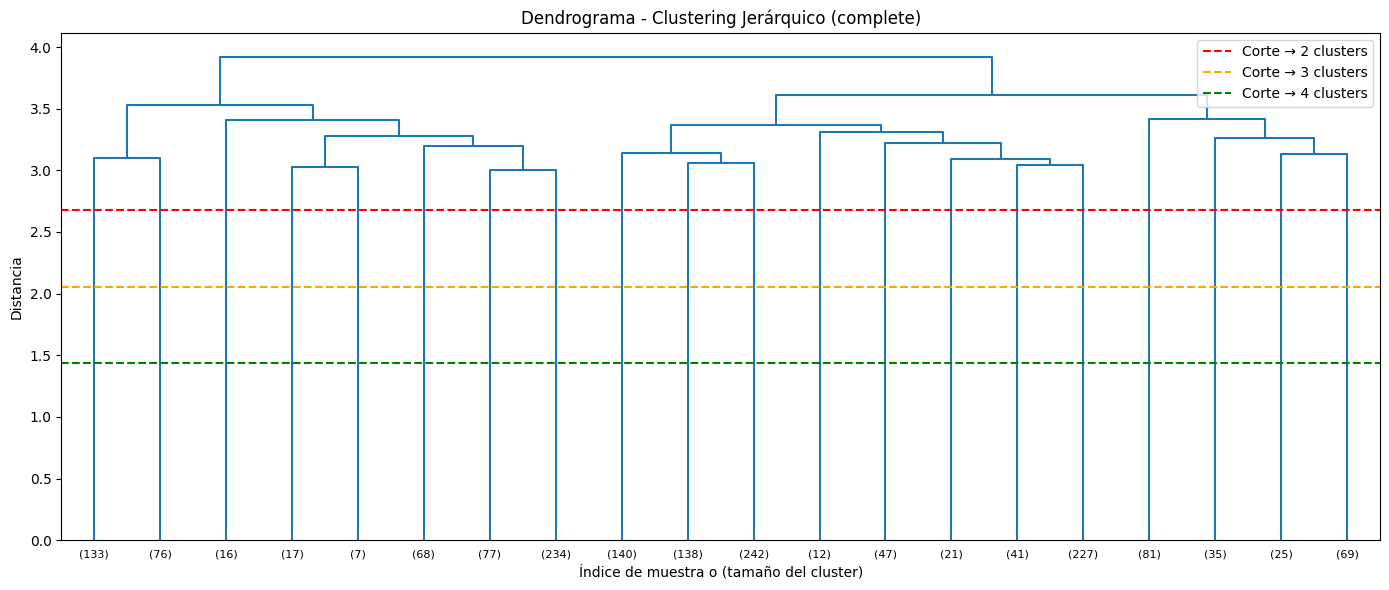

In [8]:
print("\n--- DENDROGRAMA - CLUSTERING JERÁRQUICO ---\n")

fig1 = hierarchical.plot_dendrogram(
    figsize=(16, 7),
    truncate_mode=None,
    save_path='../../figures/dendrograma_completo.png'
)

fig1.show()

fig2 = hierarchical.plot_dendrogram(
    figsize=(14, 6),
    truncate_mode='lastp',
    p=20,
    save_path='../../figures/dendrograma_truncado.png'
)

ax = fig2.gca()
colores = ['red', 'orange', 'green']
alturas = [0.65, 0.50, 0.35] 

for altura, color, n in zip(alturas, colores, [2, 3, 4]):
    ax.axhline(
        y=altura * ax.get_ylim()[1],
        color=color,
        linestyle='--',
        linewidth=1.5,
        label=f'Corte → {n} clusters'
    )

ax.legend(loc='upper right')
ax.show()

print("\nInterpretación:")
print(f"  Linkage usado: {hierarchical.linkage}")
print(f"  n_clusters actual: {hierarchical.n_clusters_}")
print(f"  Silhouette: {metrics_hc['silhouette']:.4f}")
print("\n  Las líneas de corte muestran dónde cortar el dendrograma")
print("  para obtener 2, 3 o 4 clusters.")
print("  Los saltos grandes en altura = clusters naturales en los datos.")

In [9]:
from sklearn.decomposition import PCA
import pandas as pd

print("\n--- PCA PARA DBSCAN ---\n")

pca = PCA(n_components=0.90, random_state=42)
df_pca_array = pca.fit_transform(df)

df_pca = pd.DataFrame(
    df_pca_array,
    columns=[f"PCA_{i+1}" for i in range(df_pca_array.shape[1])]
)

print(f"Dimensiones originales: {df.shape[1]}")
print(f"Dimensiones PCA: {df_pca.shape[1]}")
print(f"Varianza explicada: {pca.explained_variance_ratio_.sum():.4f}")



--- PCA PARA DBSCAN ---

Dimensiones originales: 28
Dimensiones PCA: 18
Varianza explicada: 0.9084



--- BUSQUEDA DE CONFIGURACIÓN - DBSCAN ---

ANÁLISIS DE PARÁMETROS DBSCAN
Dataset: 1706 muestras × 18 features

Regla empírica para min_samples (>= n_features = 18):
  k candidatos a explorar: [9, 18, 27, 36]

Codos detectados (eps candidatos por valor de k):
  k (min_samples)      eps en codo     interpretación
  -------------------------------------------------------
  k=9                  eps≈1.4000        conservador (más clusters, menos ruido)
  k=18                 eps≈1.4276        recomendado
  k=27                 eps≈1.5101        recomendado
  k=36                 eps≈1.5507        agresivo (menos clusters, más ruido)

✓ Gráfico guardado en: C:\electocluster\results/clustering/kdistance_plot.png


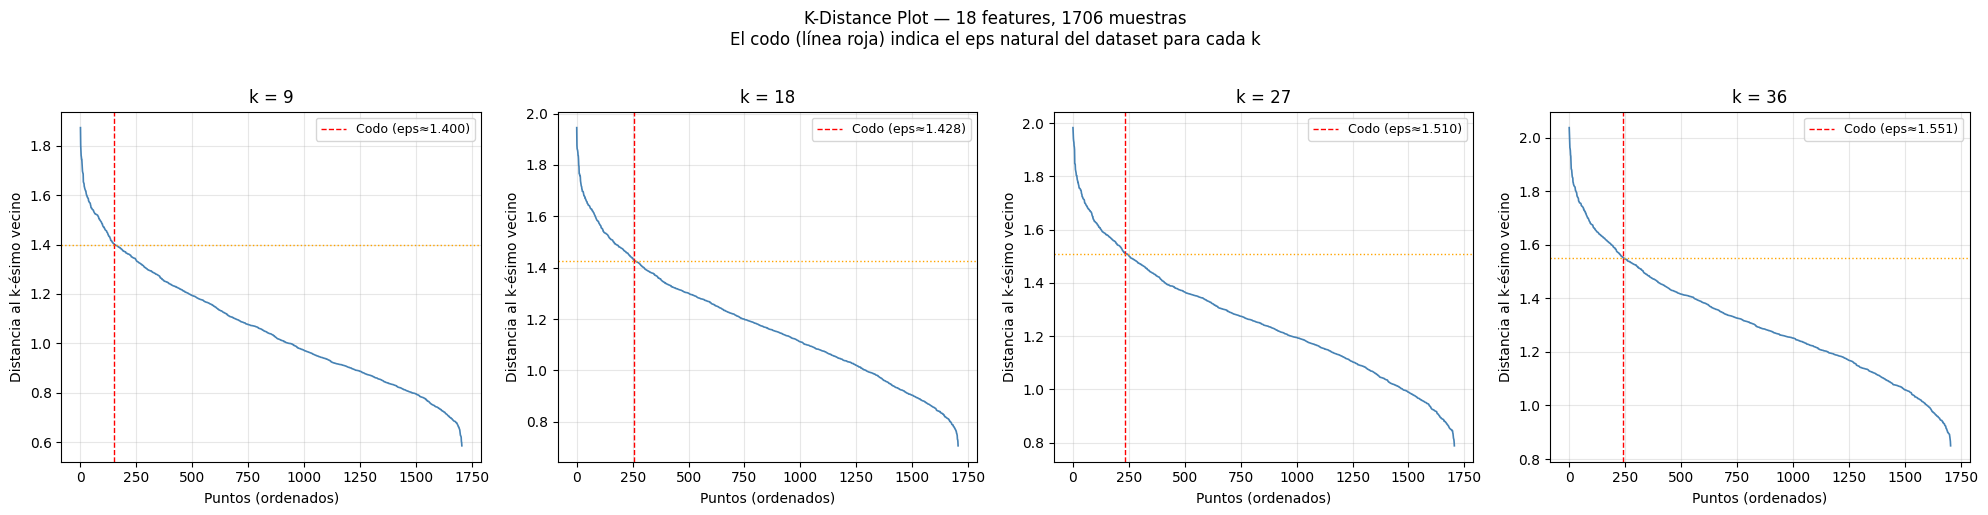


ESPACIO DE BÚSQUEDA RECOMENDADO
  eps:          [0.98, 1.153, 1.326, 1.499, 1.672, 1.845, 2.018]
  min_samples:  [9, 18, 27, 36]

  Combinaciones totales: 28

Eps candidatos por valor de k:
  k=9      eps_codo=1.4        rango=[0.5846, 1.8738]
  k=18     eps_codo=1.4276     rango=[0.7061, 1.9455]
  k=27     eps_codo=1.5101     rango=[0.788, 1.9833]
  k=36     eps_codo=1.5507     rango=[0.8495, 2.0373]

Espacio de búsqueda derivado:
  eps:         [0.98, 1.153, 1.326, 1.499, 1.672, 1.845, 2.018]
  min_samples: [9, 18, 27, 36]
  Combinaciones totales: 28


In [10]:
print("\n--- BUSQUEDA DE CONFIGURACIÓN - DBSCAN ---\n")

import matplotlib.pyplot as plt
from src.utils.params_search import analyze_dbscan_params, build_dbscan_configs
from src.utils.constants import RESULTS_PATH

analisis = analyze_dbscan_params(
    df_pca,
    output_path=f"{RESULTS_PATH}/clustering/kdistance_plot.png"
)

plt.show()

# Resultados del análisis
print("\nEps candidatos por valor de k:")
for k, datos in analisis['analisis_por_k'].items():
    print(f"  k={k:<6} eps_codo={datos['eps_codo']:<10} "
          f"rango=[{datos['distancia_min']}, {datos['distancia_max']}]")

espacio = analisis['espacio_sugerido']
print(f"\nEspacio de búsqueda derivado:")
print(f"  eps:         {espacio['eps']['valores']}")
print(f"  min_samples: {espacio['min_samples']['valores']}")
print(f"  Combinaciones totales: "
      f"{len(espacio['eps']['valores']) * len(espacio['min_samples']['valores'])}")

configs = build_dbscan_configs(analisis)

In [11]:
print("\n--- TEST DBSCAN ---\n")

mejor_config = None
mejor_sil = -1

for cfg in configs:
    db_temp = DBSCAN(**cfg)
    db_temp.fit(df_pca)
    if db_temp.n_clusters_ >= 2:
        mask = db_temp.labels_ != -1
        sil = calculate_metrics(df_pca[mask], db_temp.labels_[mask])['silhouette']
        print(f"  eps={cfg['eps']}, min_samples={cfg['min_samples']}: "
              f"{db_temp.n_clusters_} clusters, Sil={sil:.4f}")
        if sil > mejor_sil:
            mejor_sil = sil
            mejor_config = cfg
            dbscan = db_temp
    else:
        print(f"  eps={cfg['eps']}, min_samples={cfg['min_samples']}: sin clusters")

if mejor_config:
    print(f"\n✓ Mejor configuración: {mejor_config} → Sil={mejor_sil:.4f}")
else:
    print("⚠ Ninguna configuración generó clusters válidos")

print(f"\nConfiguración final: eps={dbscan.eps}, min_samples={dbscan.min_samples}")
print(f"Clusters identificados: {dbscan.n_clusters_}")
print(f"Puntos de ruido: {dbscan.n_noise_points_}")
print(f"\nTamaños:")
print(dbscan.get_cluster_sizes())

# Métricas (solo si hay suficientes clusters)
if dbscan.n_clusters_ >= 2:
    # Filtrar noise
    mask = dbscan.labels_ != -1
    df_clean = df_pca[mask]
    labels_clean = dbscan.labels_[mask]
    
    print("\nMétricas (sin ruido):")
    metrics_db = calculate_metrics(df_clean, labels_clean)
else:
    print("\n⚠ DBSCAN no generó clusters válidos con ninguna configuración")
    print("  Esto puede ocurrir en datos de alta dimensionalidad")
    print("  DBSCAN requiere ajuste manual de parámetros según el dataset")
    metrics_db = None

print("="*70)


--- TEST DBSCAN ---

Entrenando DBSCAN (eps=0.98, min_samples=9)...
✓ DBSCAN entrenado:
  Clusters identificados: 18
  Puntos de ruido: 581 (34.06%)
  Puntos core: 770
Calculando métricas de validación...
  Muestras: 1125
  Clusters: 18
  ✓ Silhouette Score: 0.1828
  ✓ Davies-Bouldin Index: 1.5921
  ✓ Calinski-Harabasz Index: 85.1165
  eps=0.98, min_samples=9: 18 clusters, Sil=0.1828
Entrenando DBSCAN (eps=0.98, min_samples=18)...
✓ DBSCAN entrenado:
  Clusters identificados: 13
  Puntos de ruido: 815 (47.77%)
  Puntos core: 395
Calculando métricas de validación...
  Muestras: 891
  Clusters: 13
  ✓ Silhouette Score: 0.2230
  ✓ Davies-Bouldin Index: 1.6191
  ✓ Calinski-Harabasz Index: 106.8608
  eps=0.98, min_samples=18: 13 clusters, Sil=0.2230
Entrenando DBSCAN (eps=0.98, min_samples=27)...
✓ DBSCAN entrenado:
  Clusters identificados: 9
  Puntos de ruido: 1039 (60.90%)
  Puntos core: 205
Calculando métricas de validación...
  Muestras: 667
  Clusters: 9
  ✓ Silhouette Score: 0.2302


### METRICAS Y RESUMEN

In [12]:
print("\n--- COMPARACIÓN DE ALGORITMOS Y METRICAS ---\n")

# Tabla comparativa
comparison_data = {
    'Algoritmo': ['K-Medoids', 'Hierarchical', 'DBSCAN'],
    'Clusters': [kmedoids.n_clusters_, hierarchical.n_clusters_, dbscan.n_clusters_],
    'Silhouette': [
        metrics_km['silhouette'], 
        metrics_hc['silhouette'],
        metrics_db['silhouette'] if metrics_db else np.nan
    ],
    'Davies-Bouldin': [
        metrics_km['davies_bouldin'],
        metrics_hc['davies_bouldin'],
        metrics_db['davies_bouldin'] if metrics_db else np.nan
    ],
    'Calinski-Harabasz': [
        metrics_km['calinski_harabasz'],
        metrics_hc['calinski_harabasz'],
        metrics_db['calinski_harabasz'] if metrics_db else np.nan
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

print("\n" + "="*70)
print("✓ TEST COMPLETADO")
print("="*70)


--- COMPARACIÓN DE ALGORITMOS Y METRICAS ---

   Algoritmo  Clusters  Silhouette  Davies-Bouldin  Calinski-Harabasz
   K-Medoids         2    0.117812        2.654580         230.887484
Hierarchical         2    0.133941        2.459568         255.546128
      DBSCAN         6    0.261426        1.500838         128.896875

✓ TEST COMPLETADO



--- PERFIL SOCIOPOLÍTICO DE CLUSTERS ---


===== K-Medoids =====

Media de variables por cluster:
          edre  q10inc   etid  boletidnew  boletidnewb  estratopri     ur  \
cluster                                                                     
0        0.718   0.248  0.238       0.348        0.098       0.388  0.949   
1        0.591   0.185  0.270       0.841        0.223       0.498  0.324   

         ocupoit     q2  q1tc_r  ...  estratosec  q12cn  q12bn   gi0n  \
cluster                          ...                                    
0          0.562  0.343   0.244  ...       0.208  0.152  0.097  0.176   
1          0.620  0.304   0.242  ...       0.819  0.167  0.164  0.199   

         smedia3n   q10e   q11n  leng4  wealth_index  civic_index  
cluster                                                            
0           0.237  0.615  0.232  0.167         0.673        0.220  
1           0.261  0.661  0.231  0.260         0.510        0.339  

[2 rows x 28 columns]

Tam

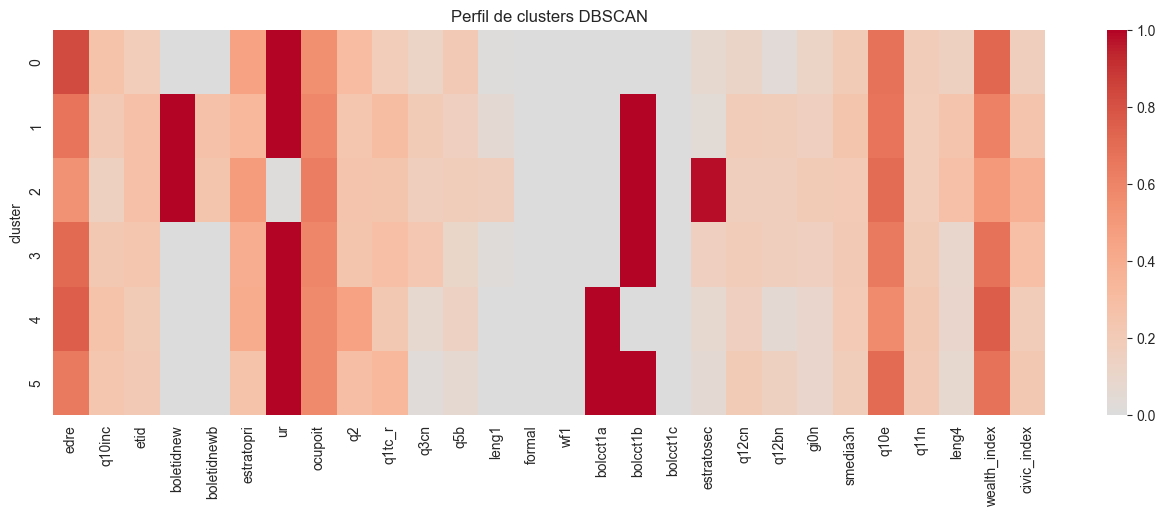

In [15]:
print("\n--- PERFIL SOCIOPOLÍTICO DE CLUSTERS ---\n")

def analizar_clusters(df_original, labels, nombre_algoritmo):
    
    df_analysis = df_original.copy()
    df_analysis['cluster'] = labels
    
    # eliminar ruido si es DBSCAN
    df_analysis = df_analysis[df_analysis['cluster'] != -1]
    
    print(f"\n===== {nombre_algoritmo} =====")
    
    resumen = df_analysis.groupby('cluster').mean()
    
    print("\nMedia de variables por cluster:")
    print(resumen.round(3))
    
    print("\nTamaño de clusters:")
    print(df_analysis['cluster'].value_counts().sort_index())
    
    return resumen


# K-Medoids
perfil_km = analizar_clusters(
    df,
    kmedoids.labels_,
    "K-Medoids"
)

# Hierarchical
perfil_hc = analizar_clusters(
    df,
    hierarchical.labels_,
    "Hierarchical"
)

# DBSCAN (solo puntos no ruido)
perfil_db = analizar_clusters(
    df,
    dbscan.labels_,
    "DBSCAN"
)

import seaborn as sns

sns.heatmap(perfil_db, cmap="coolwarm", center=0)
plt.title("Perfil de clusters DBSCAN")
plt.show()



--- VISUALIZACIÓN DE CLUSTERS ---

Aplicando PCA para reducir a 2 dimensiones...
✓ Varianza explicada: 28.32%
  PC1: 17.86%
  PC2: 10.47%


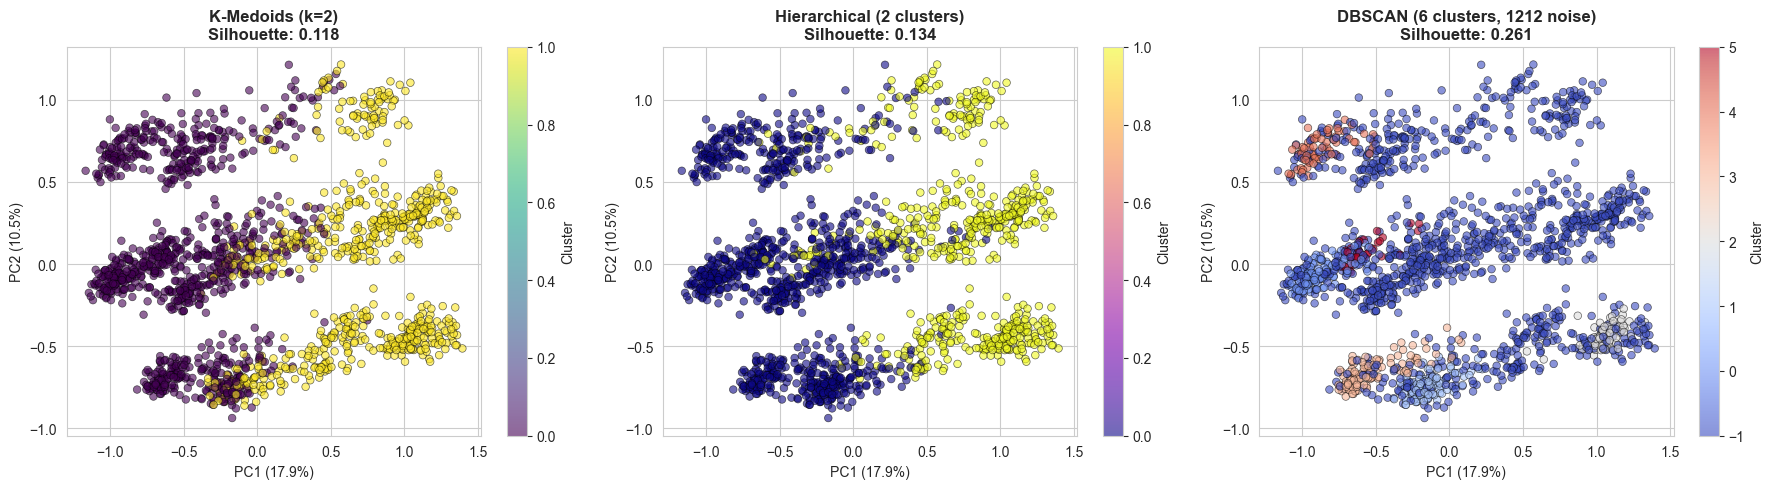


✓ Visualización guardada en: figures/comparacion_clusters_2d.png


In [14]:
print("\n--- VISUALIZACIÓN DE CLUSTERS ---\n")

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Configuración de estilo
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 5)

# Reducir dimensionalidad a 2D con PCA
print("Aplicando PCA para reducir a 2 dimensiones...")
pca = PCA(n_components=2, random_state=42)
df_2d = pca.fit_transform(df)

print(f"✓ Varianza explicada: {pca.explained_variance_ratio_.sum()*100:.2f}%")
print(f"  PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"  PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")

# Crear figura con 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ====== K-Medoids ======
scatter1 = axes[0].scatter(
    df_2d[:, 0], 
    df_2d[:, 1], 
    c=kmedoids.labels_, 
    cmap='viridis', 
    alpha=0.6,
    s=30,
    edgecolors='black',
    linewidth=0.5
)
axes[0].set_title(f'K-Medoids (k={kmedoids.n_clusters_})\nSilhouette: {metrics_km["silhouette"]:.3f}', 
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# ====== Hierarchical ======
scatter2 = axes[1].scatter(
    df_2d[:, 0], 
    df_2d[:, 1], 
    c=hierarchical.labels_, 
    cmap='plasma', 
    alpha=0.6,
    s=30,
    edgecolors='black',
    linewidth=0.5
)
axes[1].set_title(f'Hierarchical ({hierarchical.n_clusters_} clusters)\nSilhouette: {metrics_hc["silhouette"]:.3f}', 
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

# ====== DBSCAN ======
if dbscan.n_clusters_ >= 2:
    # DBSCAN con clusters válidos
    scatter3 = axes[2].scatter(
        df_2d[:, 0], 
        df_2d[:, 1], 
        c=dbscan.labels_, 
        cmap='coolwarm', 
        alpha=0.6,
        s=30,
        edgecolors='black',
        linewidth=0.5
    )
    title = f'DBSCAN ({dbscan.n_clusters_} clusters, {dbscan.n_noise_points_} noise)\nSilhouette: {metrics_db["silhouette"]:.3f}'
else:
    # DBSCAN sin clusters (todo ruido)
    scatter3 = axes[2].scatter(
        df_2d[:, 0], 
        df_2d[:, 1], 
        c='gray', 
        alpha=0.3,
        s=30,
        edgecolors='black',
        linewidth=0.5
    )
    title = f'DBSCAN (Sin clusters)\nTodos los puntos = ruido'

axes[2].set_title(title, fontsize=12, fontweight='bold')
axes[2].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[2].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
if dbscan.n_clusters_ >= 2:
    plt.colorbar(scatter3, ax=axes[2], label='Cluster')

plt.tight_layout()
plt.savefig('../../figures/comparacion_clusters_2d.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualización guardada en: figures/comparacion_clusters_2d.png")
print("="*70)